In [3]:
# # Cell 0 - Mount Google Drive (Colab only)
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# # Cell 1 - Install dependencies
# !pip install -q transformers accelerate pillow opencv-python-headless imagehash

In [5]:
# Cell 2 - Imports and device
import cv2
import os
import torch
import numpy as np
import imagehash
from PIL import Image
from IPython.display import display
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE}")

Running on: cuda


In [6]:
# Cell 3 - Paths

# --- Colab ---
VIDEO_PATH  = "/content/drive/MyDrive/Colab Notebooks/vid_1.mp4"
OUTPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/dino_detect.mp4"
CROPS_DIR   = "/content/drive/MyDrive/Colab Notebooks/dino_crops"
LOCAL_VIDEO = "/content/vid_1.mp4"

# --- Local CPU (uncomment below, comment out four lines above) ---
# VIDEO_PATH  = r"C:\UNM\CS 522_591-Digital Image Processing-Zhu Wang\Final Project\Code\DINO_SAM\vid_1.mp4"
# OUTPUT_PATH = r"C:\UNM\CS 522_591-Digital Image Processing-Zhu Wang\Final Project\Code\DINO_SAM\dino_detect.mp4"
# CROPS_DIR   = r"C:\UNM\CS 522_591-Digital Image Processing-Zhu Wang\Final Project\Code\DINO_SAM\dino_crops"
# LOCAL_VIDEO = VIDEO_PATH

os.makedirs(CROPS_DIR, exist_ok=True)
print(f"Crops dir: {CROPS_DIR}")

Crops dir: /content/drive/MyDrive/Colab Notebooks/dino_crops


In [7]:
# Cell 4 - Copy video from Drive to local Colab storage (faster I/O)
import shutil
shutil.copy(VIDEO_PATH, LOCAL_VIDEO)
VIDEO_PATH = LOCAL_VIDEO
print(f"Video ready at: {VIDEO_PATH}")

# --- Local CPU: skip this cell ---

Video ready at: /content/vid_1.mp4


In [ ]:
# Cell 5 - Load DINO model and processor
import os
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# Option A: set HF_TOKEN in your environment or leave it blank for public downloads
HF_TOKEN = os.getenv("HF_TOKEN", "")

# Option B: Colab secret manager (left sidebar → key icon → add secret named HF_TOKEN)
# from google.colab import userdata
# HF_TOKEN = userdata.get("HF_TOKEN")

MODEL_ID = "IDEA-Research/grounding-dino-tiny"
# MODEL_ID = "IDEA-Research/grounding-dino-base"

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN,
    use_fast=False
)

model = AutoModelForZeroShotObjectDetection.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN
).to(DEVICE)

model.eval()
print(f"Model loaded: {MODEL_ID}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

Model loaded: IDEA-Research/grounding-dino-tiny


In [9]:
# Cell 6 - Detection function
import transformers
_new_api = tuple(int(x) for x in transformers.__version__.split(".")[:2]) >= (4, 50)

PROMPT         = "poster . flyer . notice . bulletin"
BOX_THRESHOLD  = 0.35
TEXT_THRESHOLD = 0.25

def detect_posters(frame_bgr):
    image  = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    h, w   = frame_bgr.shape[:2]
    inputs = processor(images=image, text=PROMPT, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    if _new_api:
        results = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids,
            threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[(h, w)]
        )[0]
    else:
        results = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids,
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[(h, w)]
        )[0]

    boxes  = results["boxes"].cpu().numpy().astype(int)
    scores = results["scores"].cpu().numpy()
    labels = results["labels"]
    return boxes, scores, labels

print(f"transformers {transformers.__version__} — {'new' if _new_api else 'old'} API")

transformers 5.0.0 — new API


In [10]:
# Cell 7 - Box filter, tracker, scoring helpers
multiplier = 1.0  # adjust to tune number of detections — higher = more, lower = fewer
MIN_W          = 80*multiplier     # was 40 — reject small partial crops
MIN_H          = 100*multiplier    # was 40
MIN_AREA_RATIO = 0.02*multiplier   # was 0.005 — poster must be ≥ 2% of frame
MIN_ASPECT     = 0.2*multiplier    # keep permissive
MAX_ASPECT     = 5.0*multiplier    # keep permissive

EDGE_MARGIN = 8         # back in — rejects boxes cut off at frame boundary

TRACK_IOU_THRESH  = 0.15
TRACK_CENTER_DIST = 200

def valid_poster_box(box, frame_shape):
    fh, fw          = frame_shape[:2]
    x1, y1, x2, y2 = box
    bw, bh          = x2 - x1, y2 - y1
    if bw < MIN_W or bh < MIN_H:
        return False, "too small"
    if (bw * bh) / float(fw * fh) < MIN_AREA_RATIO:
        return False, "area too small"
    aspect = bw / float(bh)
    if aspect < MIN_ASPECT or aspect > MAX_ASPECT:
        return False, f"bad aspect {aspect:.2f}"
    if x1 <= EDGE_MARGIN or y1 <= EDGE_MARGIN or x2 >= fw - EDGE_MARGIN or y2 >= fh - EDGE_MARGIN:
        return False, "touches border"
    return True, "ok"

def iou(a, b):
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter  = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    return inter / float((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)

def centroid(box):
    return ((box[0]+box[2])/2.0, (box[1]+box[3])/2.0)

def dist(c1, c2):
    return ((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2) ** 0.5

def crop_score(crop, box, frame_shape):
    fh, fw   = frame_shape[:2]
    gray     = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    sharp    = cv2.Laplacian(gray, cv2.CV_64F).var()
    cx, cy   = centroid(box)
    center_d = ((cx - fw/2)**2 + (cy - fh/2)**2) ** 0.5 / ((fw/2)**2 + (fh/2)**2) ** 0.5
    area     = (box[2]-box[0]) * (box[3]-box[1])
    return sharp + area * 0.01 - center_d * 300

def pad_box(box, frame_shape, pad=8):
    fh, fw          = frame_shape[:2]
    x1, y1, x2, y2 = box
    return max(0, x1-pad), max(0, y1-pad), min(fw, x2+pad), min(fh, y2+pad)

tracks = []

def update_tracks(box, crop, frame_shape):
    c = centroid(box)
    for track in tracks:
        if iou(box, track["box"]) > TRACK_IOU_THRESH or dist(c, track["centroid"]) < TRACK_CENTER_DIST:
            track["centroid"] = c
            track["box"]      = box
            s = crop_score(crop, box, frame_shape)
            if s > track["best_score"]:
                track["best_score"] = s
                track["best_crop"]  = crop.copy()
            return
    tracks.append({
        "centroid":   c,
        "box":        box,
        "best_crop":  crop.copy(),
        "best_score": crop_score(crop, box, frame_shape),
    })

print("Filters and tracker ready.")

Filters and tracker ready.


In [11]:
# Cell 8 - Main loop: detect → filter → track → annotate video → save crops
tracks = []

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open: {VIDEO_PATH}"

fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"{total} frames @ {fps:.1f} fps  {width}x{height}")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

for frame_idx in range(total):
    ret, frame = cap.read()
    if not ret:
        break

    boxes, scores, labels = detect_posters(frame)

    for box, score, label in zip(boxes, scores, labels):
        ok, reason = valid_poster_box(box, frame.shape)

        if not ok:
            # uncomment next 3 lines to see what's being rejected in RED
            # cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), (0, 0, 255), 1)
            # cv2.putText(frame, reason, (box[0], max(0, box[1]-5)),
            #             cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
            continue

        x1, y1, x2, y2 = pad_box(box, frame.shape)
        crop = frame[y1:y2, x1:x2]
        update_tracks(box, crop, frame.shape)

        cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        cv2.putText(frame, f"{label} {score:.2f}", (box[0], max(0, box[1]-8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    writer.write(frame)

    if frame_idx % 30 == 0:
        print(f"  frame {frame_idx}/{total}  tracks: {len(tracks)}")

cap.release()
writer.release()

# recreate folder in case it was deleted before this run
os.makedirs(CROPS_DIR, exist_ok=True)

for i, track in enumerate(tracks):
    cv2.imwrite(f"{CROPS_DIR}/poster_{i:03d}.jpg", track["best_crop"])

print(f"\nDone. {len(tracks)} tracks saved → {CROPS_DIR}")
print(f"Video → {OUTPUT_PATH}")

646 frames @ 29.7 fps  1280x720


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


  frame 0/646  tracks: 1
  frame 30/646  tracks: 1
  frame 60/646  tracks: 1
  frame 90/646  tracks: 2
  frame 120/646  tracks: 3
  frame 150/646  tracks: 3
  frame 180/646  tracks: 3
  frame 210/646  tracks: 3
  frame 240/646  tracks: 3
  frame 270/646  tracks: 4
  frame 300/646  tracks: 7
  frame 330/646  tracks: 10
  frame 360/646  tracks: 10
  frame 390/646  tracks: 11
  frame 420/646  tracks: 11
  frame 450/646  tracks: 12
  frame 480/646  tracks: 12
  frame 510/646  tracks: 12
  frame 540/646  tracks: 13
  frame 570/646  tracks: 13
  frame 600/646  tracks: 13
  frame 630/646  tracks: 13

Done. 13 tracks saved → /content/drive/MyDrive/Colab Notebooks/dino_crops
Video → /content/drive/MyDrive/Colab Notebooks/dino_detect.mp4


In [12]:
# Cell 9 - Perceptual hash dedup (primary dedup mechanism)
HASH_THRESHOLD = 15   # lower to 10 if different posters merge; raise to 20 if duplicates remain

if not os.path.exists(CROPS_DIR):
    print("Crops folder not found — run Cell 8 first.")
else:
    crop_files = sorted([
        os.path.join(CROPS_DIR, f)
        for f in os.listdir(CROPS_DIR) if f.endswith(".jpg")
    ])
    print(f"{len(crop_files)} crops before dedup")

    if len(crop_files) == 0:
        print("No crops found — nothing to dedup.")
    else:
        hashes  = [(fpath, imagehash.phash(Image.open(fpath).convert("RGB"))) for fpath in crop_files]
        kept    = []
        removed = []

        for fpath, h in hashes:
            is_dup = False
            for i, (kpath, kh) in enumerate(kept):
                if abs(h - kh) <= HASH_THRESHOLD:
                    if os.path.getsize(fpath) > os.path.getsize(kpath):
                        removed.append(kpath)
                        kept[i] = (fpath, h)
                    else:
                        removed.append(fpath)
                    is_dup = True
                    break
            if not is_dup:
                kept.append((fpath, h))

        for f in removed:
            os.remove(f)

        print(f"{len(kept)} unique posters kept")
        print(f"{len(removed)} duplicates removed")

13 crops before dedup
9 unique posters kept
4 duplicates removed


9 final posters

poster_001.jpg


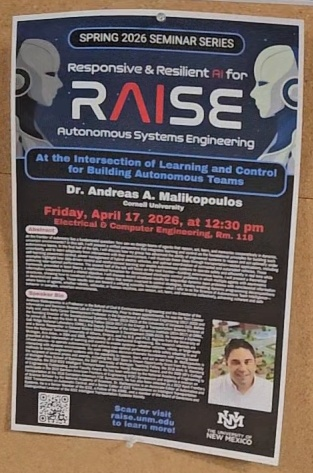

poster_002.jpg


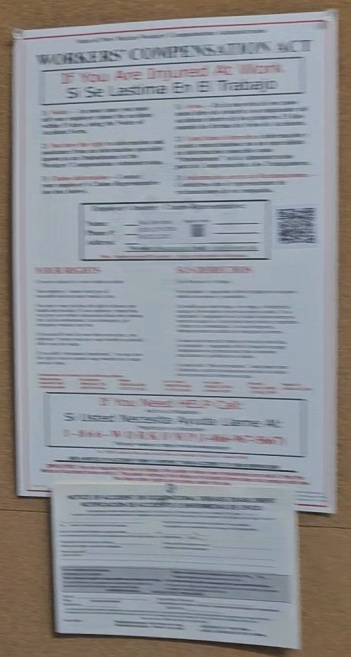

poster_003.jpg


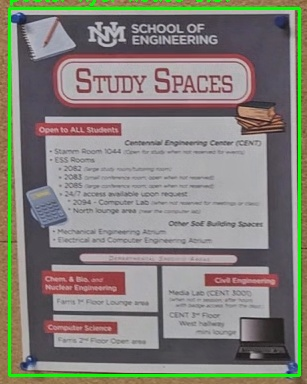

poster_004.jpg


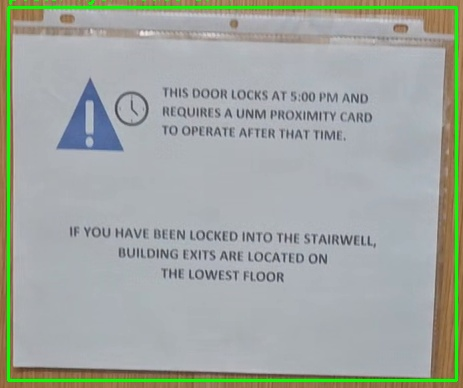

poster_005.jpg


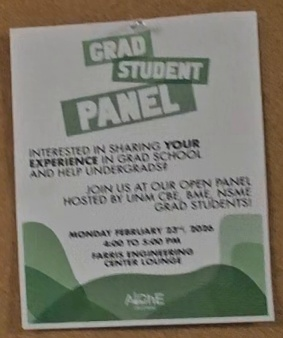

poster_007.jpg


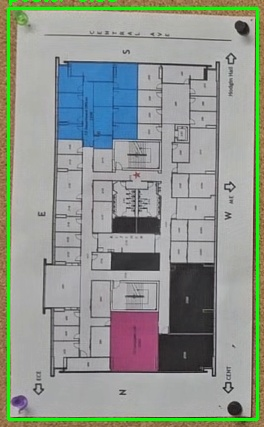

poster_008.jpg


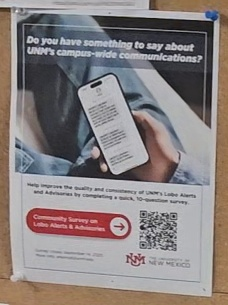

poster_009.jpg


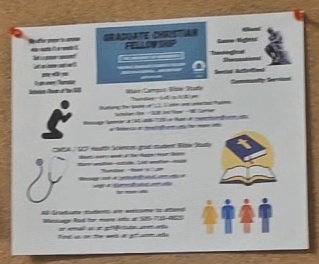

poster_010.jpg


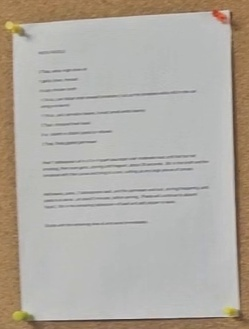

In [13]:
# Cell 10 - Preview final unique crops
final = sorted([f for f in os.listdir(CROPS_DIR) if f.endswith(".jpg")])
print(f"{len(final)} final posters\n")

for fname in final:
    img = Image.open(os.path.join(CROPS_DIR, fname))
    print(fname)
    display(img)